In [3]:
import pandas as pd
import pandas as pd

url = "https://raw.githubusercontent.com/mxrci580/costumer_churn_project/main/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.drop('customerID', axis=1, inplace=True)

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.dtypes


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [8]:
df.isnull().sum()


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [9]:
df = df.dropna()

In [10]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


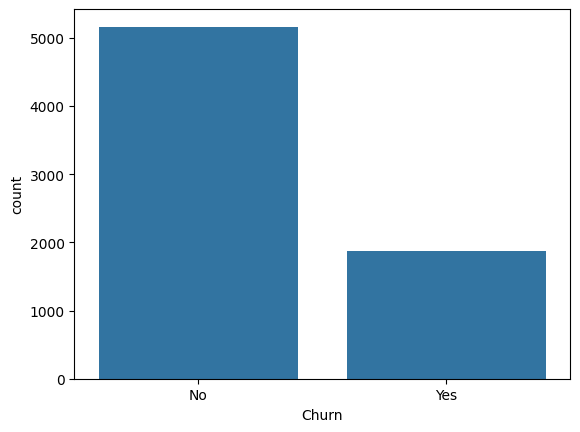

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

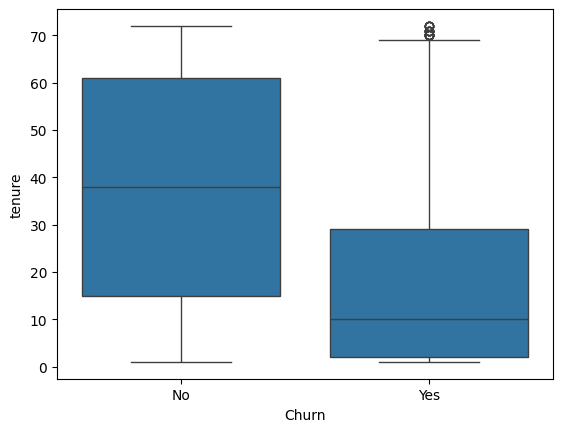

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

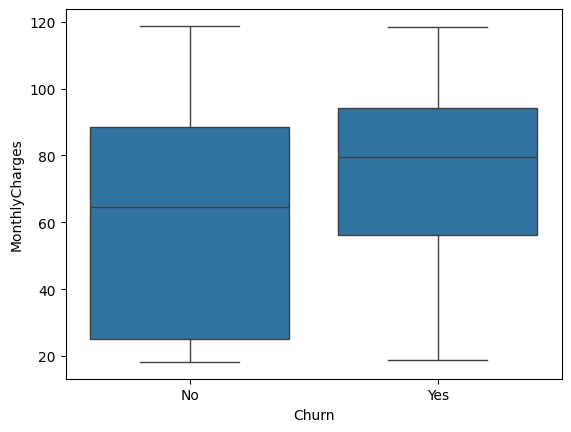

In [13]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

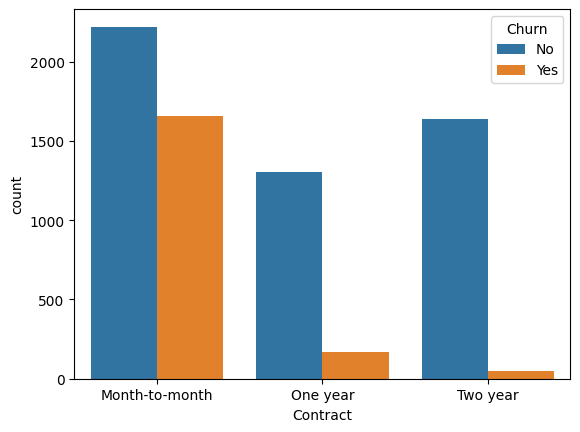

In [14]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()


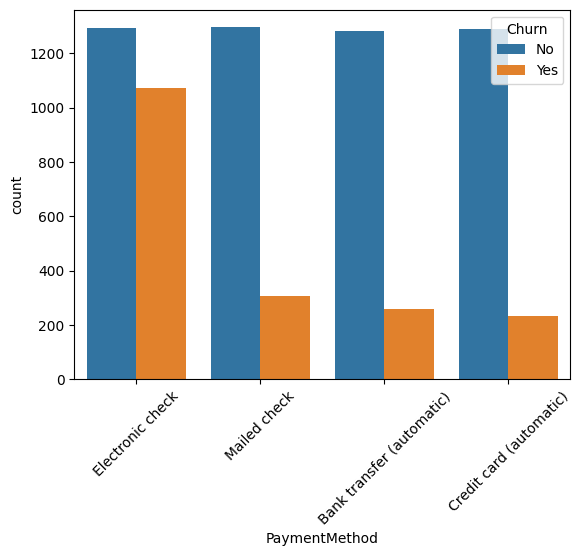

In [15]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()


python dont understand text so we've to convert them to numbers by using one-hot encoding

In [16]:
df.select_dtypes(include=['object']).columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [17]:
df = pd.get_dummies(df, drop_first=True)


In [19]:
df = df.astype(int)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

In [20]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29,29,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56,1889,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53,108,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42,1840,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70,151,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7882018479033405

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
 [[916 117]
 [181 193]]


In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

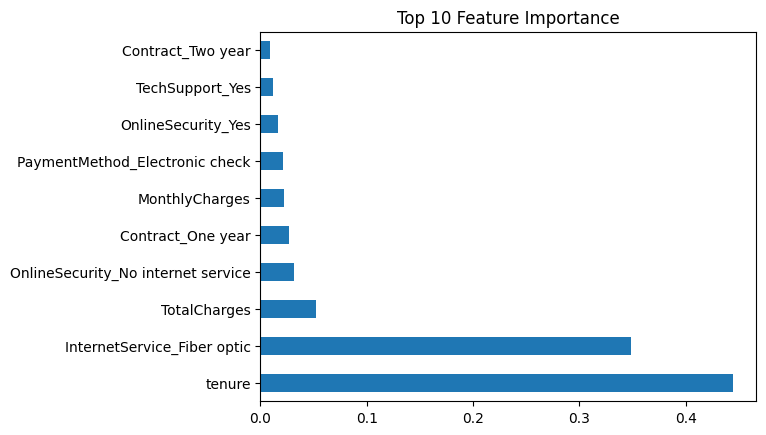

In [26]:
importance = pd.Series(dt_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
importance.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.gca().invert_yaxis
plt.show()

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.7761194029850746

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407


Confusion Matrix:
 [[868 165]
 [150 224]]


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7761194029850746

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.85      1033
           1       0.61      0.44      0.51       374

    accuracy                           0.78      1407
   macro avg       0.71      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407


Confusion Matrix:
 [[928 105]
 [210 164]]


In [30]:
import pandas as pd

importance = pd.Series(dt_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

tenure                                0.444397
InternetService_Fiber optic           0.348665
TotalCharges                          0.052169
OnlineSecurity_No internet service    0.031836
Contract_One year                     0.026401
MonthlyCharges                        0.022445
PaymentMethod_Electronic check        0.021605
OnlineSecurity_Yes                    0.016038
TechSupport_Yes                       0.011663
Contract_Two year                     0.009325
dtype: float64


<Axes: >

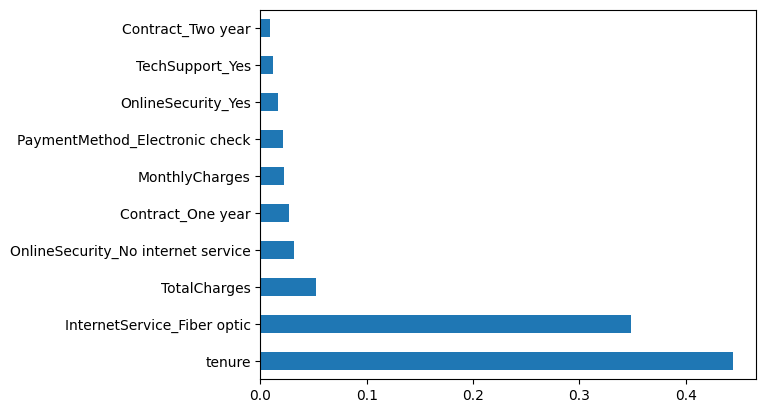

In [31]:
importance.head(10).plot(kind='barh')

In [32]:
!pip install streamlit pyngrok
import pickle
pickle.dump(dt_model, open("model.pkl", "wb"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.9 MB/s eta 0:00:00


In [33]:
!ls

model.pkl  sample_data


In [34]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("model.pkl", "rb"))

st.title("📊 Customer Churn Prediction")
st.markdown("Fill in the customer details below:")

# --- Basic Info ---
st.subheader("Basic Info")
senior = st.selectbox("Senior Citizen", ["No", "Yes"])
gender = st.selectbox("Gender", ["Female", "Male"])
partner = st.selectbox("Has Partner?", ["No", "Yes"])
dependents = st.selectbox("Has Dependents?", ["No", "Yes"])
tenure = st.number_input("Tenure (months)", min_value=0, max_value=72, value=12)

# --- Services ---
st.subheader("Services")
phone = st.selectbox("Phone Service", ["No", "Yes"])
multiple_lines = st.selectbox("Multiple Lines", ["No", "No phone service", "Yes"])
internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
online_security = st.selectbox("Online Security", ["No", "No internet service", "Yes"])
online_backup = st.selectbox("Online Backup", ["No", "No internet service", "Yes"])
device_protection = st.selectbox("Device Protection", ["No", "No internet service", "Yes"])
tech_support = st.selectbox("Tech Support", ["No", "No internet service", "Yes"])
streaming_tv = st.selectbox("Streaming TV", ["No", "No internet service", "Yes"])
streaming_movies = st.selectbox("Streaming Movies", ["No", "No internet service", "Yes"])

# --- Billing ---
st.subheader("Billing")
contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
paperless = st.selectbox("Paperless Billing", ["No", "Yes"])
payment = st.selectbox("Payment Method", [
    "Bank transfer (automatic)",
    "Credit card (automatic)",
    "Electronic check",
    "Mailed check"
])
monthly = st.number_input("Monthly Charges ($)", min_value=0.0, max_value=200.0, value=65.0)
total = st.number_input("Total Charges ($)", min_value=0.0, max_value=10000.0, value=800.0)

# --- Predict ---
if st.button("Predict Churn"):

    # Replicate get_dummies(drop_first=True) encoding
    features = {
        "SeniorCitizen":                            1 if senior == "Yes" else 0,
        "tenure":                                   tenure,
        "MonthlyCharges":                           monthly,
        "TotalCharges":                             total,
        "gender_Male":                              1 if gender == "Male" else 0,
        "Partner_Yes":                              1 if partner == "Yes" else 0,
        "Dependents_Yes":                           1 if dependents == "Yes" else 0,
        "PhoneService_Yes":                         1 if phone == "Yes" else 0,
        "MultipleLines_No phone service":           1 if multiple_lines == "No phone service" else 0,
        "MultipleLines_Yes":                        1 if multiple_lines == "Yes" else 0,
        "InternetService_Fiber optic":              1 if internet == "Fiber optic" else 0,
        "InternetService_No":                       1 if internet == "No" else 0,
        "OnlineSecurity_No internet service":       1 if online_security == "No internet service" else 0,
        "OnlineSecurity_Yes":                       1 if online_security == "Yes" else 0,
        "OnlineBackup_No internet service":         1 if online_backup == "No internet service" else 0,
        "OnlineBackup_Yes":                         1 if online_backup == "Yes" else 0,
        "DeviceProtection_No internet service":     1 if device_protection == "No internet service" else 0,
        "DeviceProtection_Yes":                     1 if device_protection == "Yes" else 0,
        "TechSupport_No internet service":          1 if tech_support == "No internet service" else 0,
        "TechSupport_Yes":                          1 if tech_support == "Yes" else 0,
        "StreamingTV_No internet service":          1 if streaming_tv == "No internet service" else 0,
        "StreamingTV_Yes":                          1 if streaming_tv == "Yes" else 0,
        "StreamingMovies_No internet service":      1 if streaming_movies == "No internet service" else 0,
        "StreamingMovies_Yes":                      1 if streaming_movies == "Yes" else 0,
        "Contract_One year":                        1 if contract == "One year" else 0,
        "Contract_Two year":                        1 if contract == "Two year" else 0,
        "PaperlessBilling_Yes":                     1 if paperless == "Yes" else 0,
        "PaymentMethod_Credit card (automatic)":    1 if payment == "Credit card (automatic)" else 0,
        "PaymentMethod_Electronic check":           1 if payment == "Electronic check" else 0,
        "PaymentMethod_Mailed check":               1 if payment == "Mailed check" else 0,
    }

    input_array = np.array([list(features.values())])
    prediction = model.predict(input_array)

    if prediction[0] == 1:
        st.error("⚠️ This customer is likely to CHURN!")
    else:
        st.success("✅ This customer is likely to STAY!")

Writing app.py


In [35]:
!nohup streamlit run app.py > log.txt 2>&1 &

In [36]:
from pyngrok import ngrok

ngrok.set_auth_token("3CWTNpugVwL2SpLdXcTSceDngFL_2U4TmxDFJ1gKb9V1EqFi3")

In [37]:
!streamlit run app.py &>/dev/null &

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vantage-dandruff-platinum.ngrok-free.dev" -> "http://localhost:8501"
